In [1]:
import os
input_name = "ky copy.jpg"
base_name = os.path.splitext(input_name)[0]

building_map_name = f"{base_name}_building_map.png" #raster of buildings only
input_raster = building_map_name  # binary or probability raster
output_geojson = "f{base_name}.geojson"

In [32]:
import matplotlib.pyplot as plt
def visualise(mask, figsize = (18,18)):
    plt.figure(figsize = figsize)
    plt.imshow(building_map, cmap='gray', vmin=0, vmax=1)
    # plt.title("Cleaned Binary Mask")
    plt.axis('off')  # Hide axes for cleaner look
    plt.show()

def pt(x):
    print(type(x))

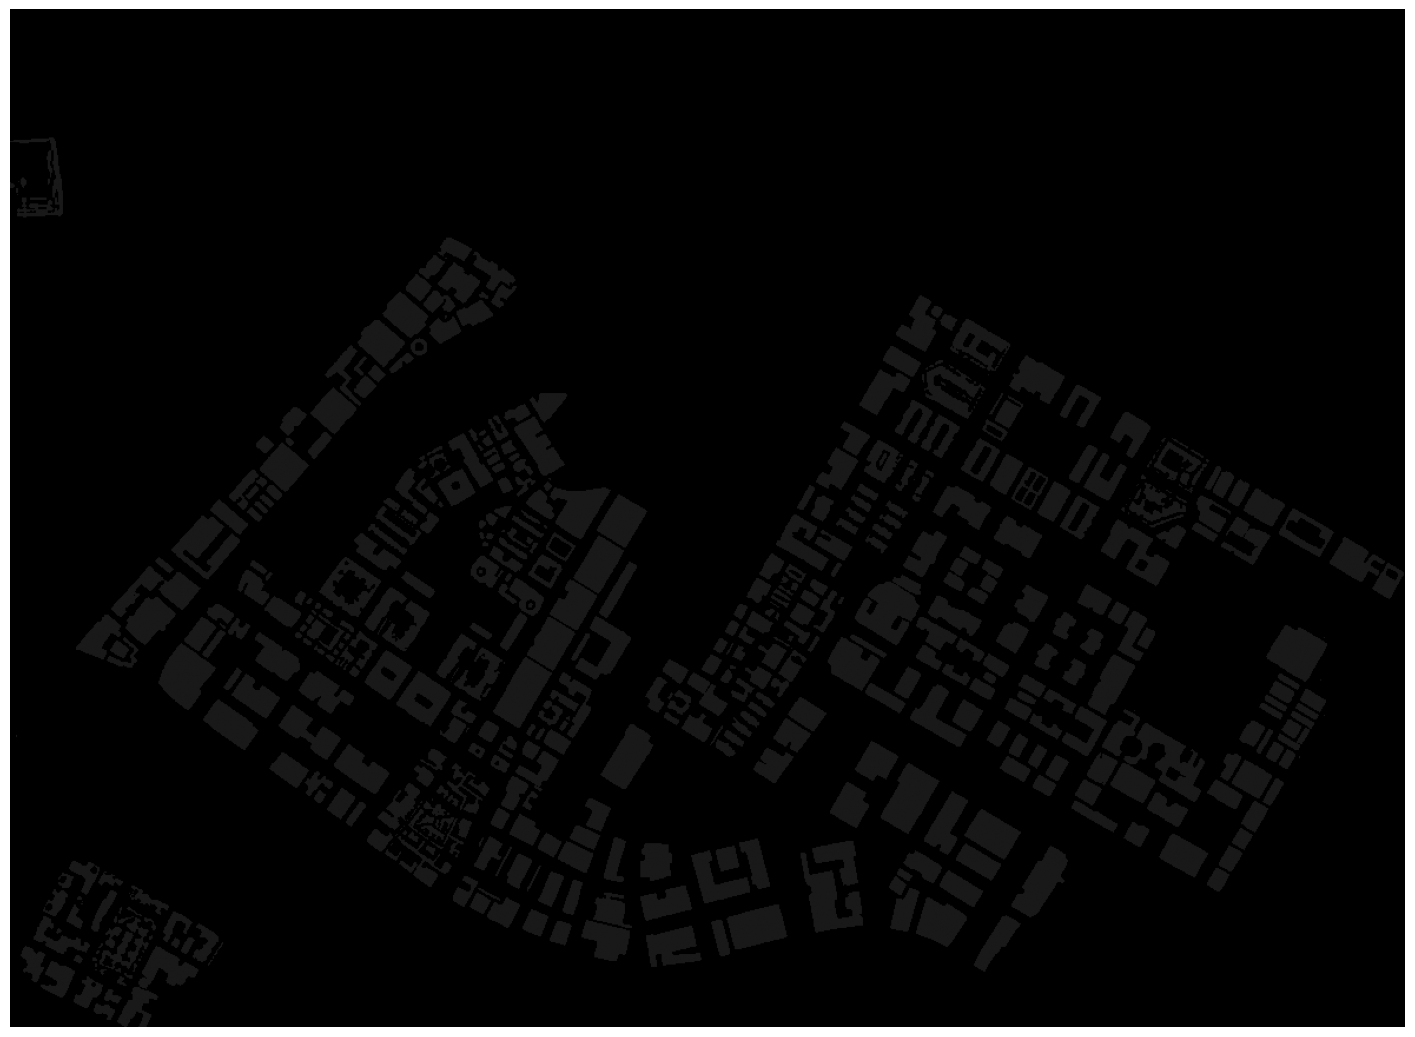

True

In [33]:
import cv2
import numpy as np
import rasterio
from rasterio.features import shapes
import numpy as np
from skimage import measure, morphology
from shapely.geometry import shape, mapping
import fiona
import json

# Load image
img = cv2.imread(input_name)  # BGR format in OpenCV

# Split channels
b, g, r = cv2.split(img)

# Define threshold for red detection
threshold = 100 # tweak as needed

# Create binary mask: 1 if red is strong and green/blue are weak
building_map = np.where((r > threshold) & (g < threshold) & (b < threshold), 0.1, 0)
visualise(building_map)
# https://share.google/HfCNy0A1qpiEgH89U to visualise what is being filtered
# Optional: save as grayscale image
cv2.imwrite(building_map_name, (building_map * 255).astype(np.uint8))

In [29]:
input_raster = building_map_name  # binary or probability raster
output_geojson = "ky2_buildings.geojson"
threshold = 0.5                     # if probability raster
simplify_tolerance = 2.0            # units in arbitrary coordinate system
min_area_pixels = 50

c:\Users\tanle\Documents\GitHub\Segmentation\.venv\Lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


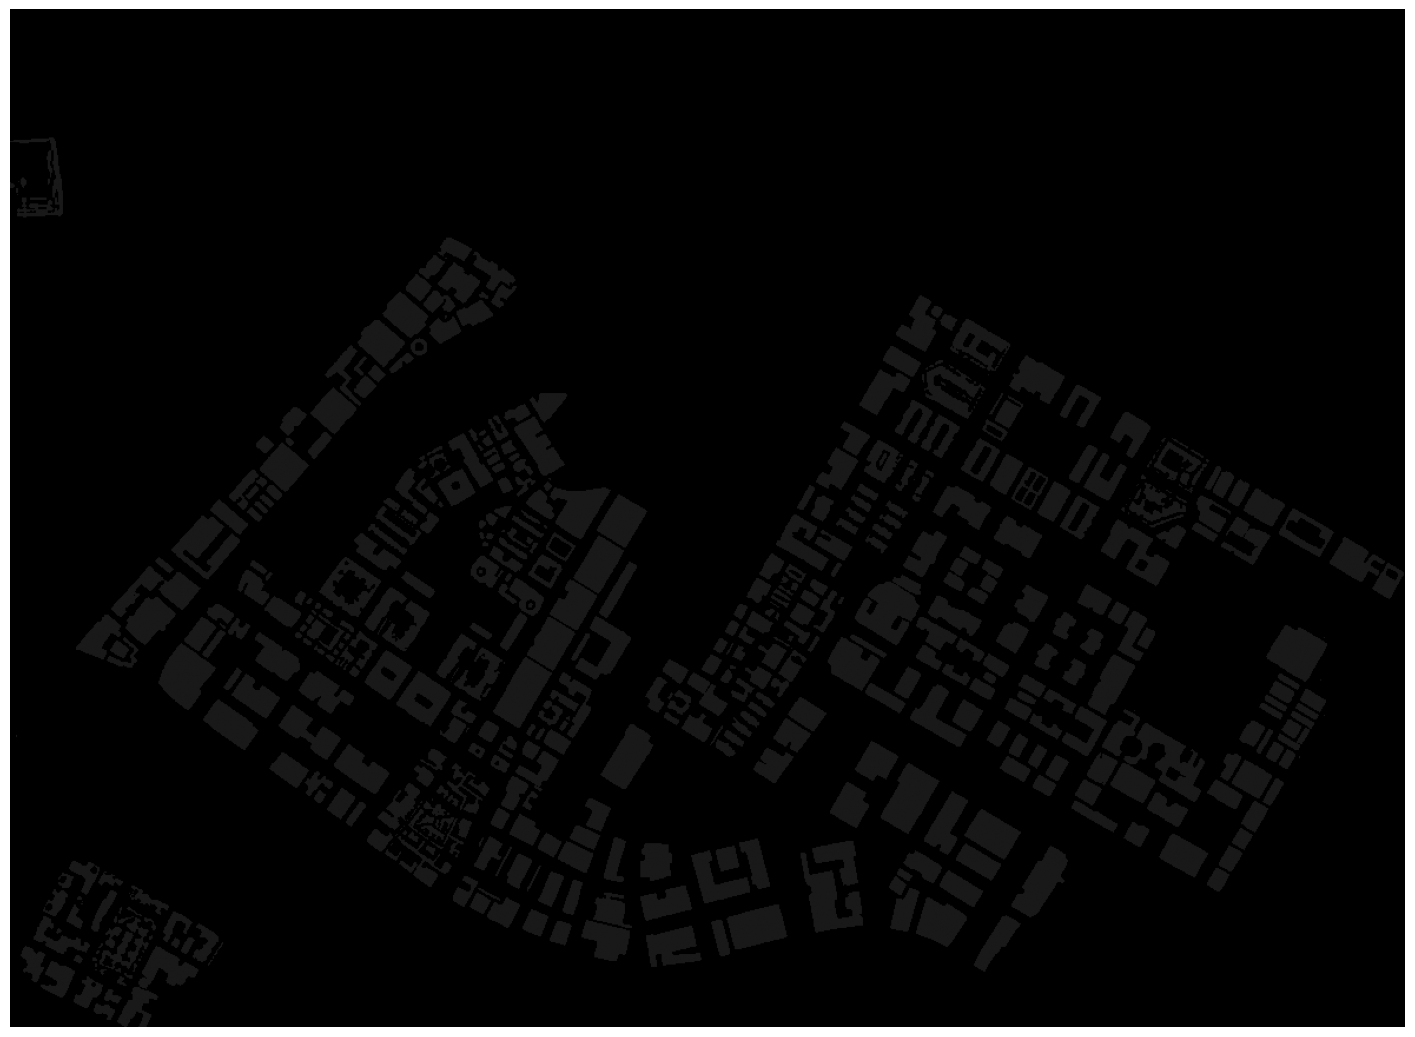

25


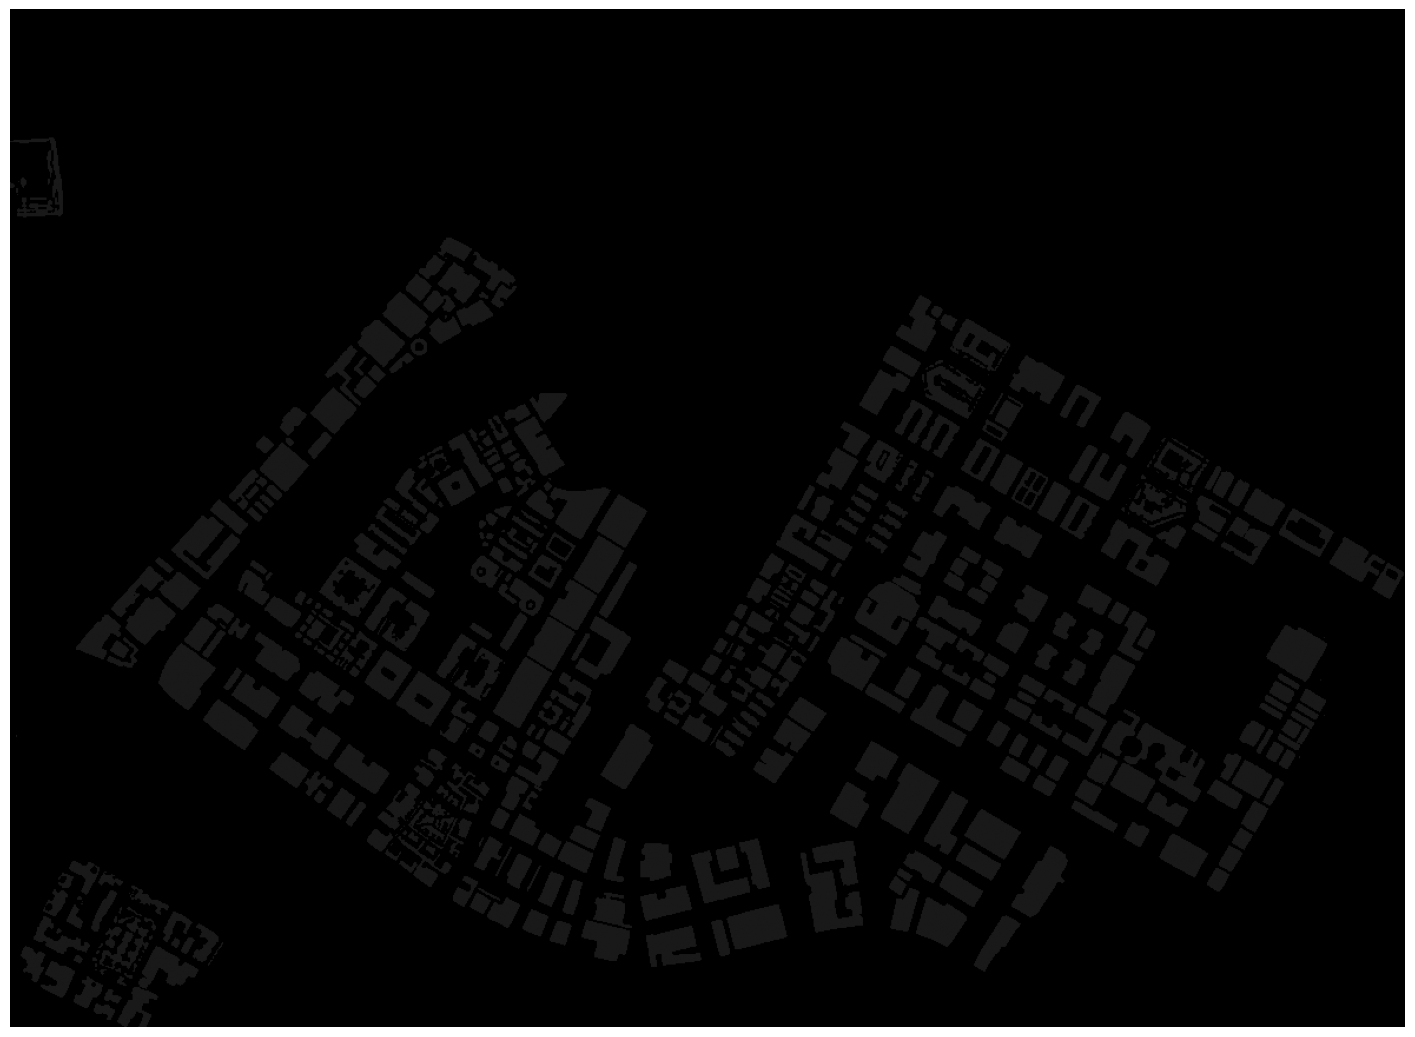

In [35]:
# Load raster
with rasterio.open(input_raster) as src:
    raster = src.read(1)
visualise(raster)
# Threshold if raster is soft probability
print(raster.max())
mask = raster > threshold
visualise(mask)